# Optimal Model

by Niklas Vogel and Kevin Stupar

## What's in this Notebook

In this notebook we want to train a model to classify rice images into 5 classes.
For the model, we will use ca. 400'000 parameter. Since we will use images, those are more than enough parameters to achieve optimum accuracy.
After training the model, we evaluate the model by running it on some images and compare it to the real data. We expect a 999% accuracy after 20 Epachs.
We will also see how the accuracy evolves over time during the training process and compare it with the other models trained in the other notebooks.

## Execution
To execute this notebook we recommend to use linux, since the training of the model is drastically quicker on Linux than on Windows.
WSL is also quite slow.

## Setup
Before execute make sure the setup script has been executed.
The setup is downloading the data and removing excess data.

## Data Credit
TODO

# Data loading

## Loading and Splitting
Using the helper function we load the data from the filesystem and split it into train, validation and test data splits.

## Image Classes
We loadaded 5 Classes (labels), each containing 4000 images, except the `Karacadag` class, which only contains 150 images.

## Resizing
We load the images downscaled to a 64x64 image, since we do not need most of the data, but the image has quite a great amount of padding around the rice corn (see further down)

In [4]:
from tensorflow.keras import layers, models, regularizers
from helper import *

image_size = (64, 64)
batch_size = 32

(all_images, train_images, validation_images, test_images, label_names) = get_data(image_size)

Number of training images:  5683
Number of validation images:  1420
Number of testing images:  3045
Class names:  ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# Inspecting the data

Before we use the data to train, we want to see the different rice corns, so we are able to see the difference of them with our own eyes.

Since the Karacadag Class only has 150 samples, we probably won't see them here.

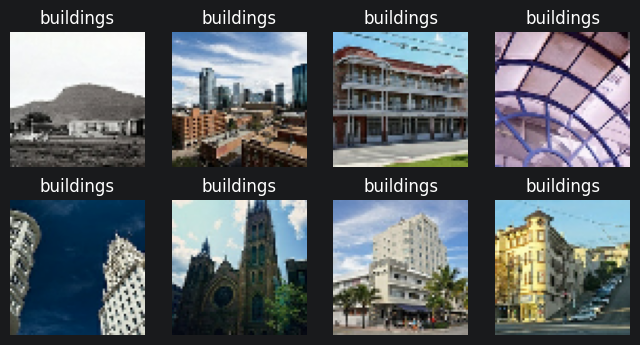

In [2]:
plot_samples(all_images, label_names)

Here we can see that all classes have exactly 4000 images, except for Karacadag, which only has 150 images.
This should lead to a worse performance of this class.

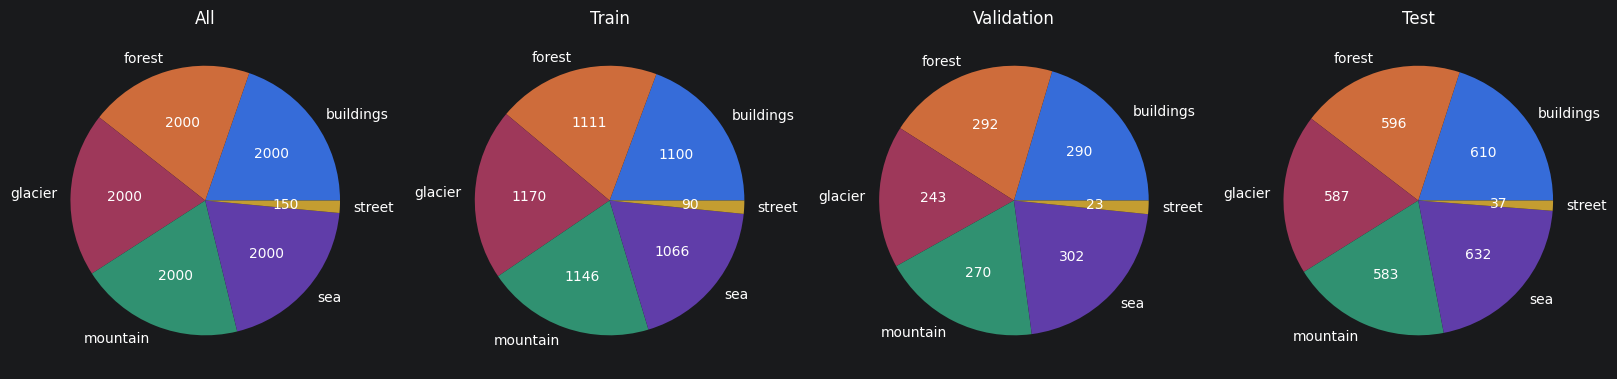

In [3]:
plot_numbers_per_classes({"All": all_images, "Train": train_images, "Validation": validation_images, "Test": test_images}, label_names)

# Building the model

Since we want an overfitting model (ca. 400'000 parameters) we use 5 layers. between each we scale down the image using a max pooling.
4 of the 5 layers are Convolutional layers, working in a 3x3 area. Starting from 256 Kernels (halving every layer).
In the last layer we flatten the image from two dimensions into one and feed it onto a Dense layer. Which in outputs 5 nodes, each for one rice class, so we can know, which has the highest probability.

As we can see in the summary below, the second layer has the most parameters, since the previous layer had 256 kernels, where as the first has only 3.

In [4]:
def create_model():
    dropout = 0.4
    regularizer = regularizers.l2(0.0015)

    new_model = models.Sequential([
        layers.Input(shape=image_size + (3,)),
        layers.Rescaling(1./255),

        layers.Conv2D(128, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu", kernel_regularizer=regularizer),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(32, (3,3), activation="relu", kernel_regularizer=regularizer),

        layers.Flatten(),
        layers.Dropout(dropout),
        layers.Dense(len(label_names), activation="softmax", kernel_regularizer=regularizer)
    ])
    new_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return new_model

model = create_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,846 (530.65 KB)

 Trainable params: 135,846 (530.65 KB)

 Non-trainable params: 0 (0.00 B)

# Compiling and Training the model

Here we compile the model and train it using the train and validation data.
We chose to use 30 Epochs here, so we can see clearly that the model is overfitting.

The training will take a while, why we recommend to use linux, since it is multiple times faster than windows.

In [5]:
history = model.fit(train_images.batch(batch_size), epochs=30, validation_data=validation_images.batch(batch_size))

Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4649 - loss: 1.3517 - val_accuracy: 0.5563 - val_loss: 1.1375
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5867 - loss: 1.0779 - val_accuracy: 0.5887 - val_loss: 1.0804
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6395 - loss: 0.9830 - val_accuracy: 0.6937 - val_loss: 0.8771
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.6620 - loss: 0.9239 - val_accuracy: 0.7148 - val_loss: 0.8312
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7123 - loss: 0.8367 - val_accuracy: 0.7261 - val_loss: 0.7889
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7338 - loss: 0.7807 - val_accuracy: 0.7866 - val_loss: 0.6894
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7556 - loss: 0.7345 - val_accuracy: 0.7845 - val_loss: 0.6675
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7748 - loss: 0.6925 - val_accu

# Evaluating the model

## Preparing
To evaluate the model we first run some images through the model and look at the predictions the model has made.

After that we use those prediction together with the true values to plot some graphs and evaluate how good the models behaves and if it really overfits.

## Plots
### Accuracy/Loss
The first two plots show us the accuracy and the loss, where the loss is in a log y-scale, to better see the difference between the Epochs.

The training accuracy rises quick and then flattens out, where as the validation fluctuates quite ab it even from the beginning.
Despite this both seem to rise slowly to 99%.

### Confusion Matrix
We have 4 diffrent Confustion matrix plotted, which show us how often and waht the images has been classified as.
Firstly we can see that the last class (Karacadag) is not beeing clasified as good aas the others, due to the fact that it only has 150 images. Despite thsi it is quite good.
Secondly we can see that the classes 2 and 4 (Basmati and Jasmine) are mistaken for each other a few times, In the iamges plotted earlier we can see that both are slim and long, which explains it.

### Scores
The last three plots show us the F-score, Precision and Recall. All of them are very high except for the last class.

In [6]:
true, pred = calculate_predictions(model, validation_images.batch(batch_size))

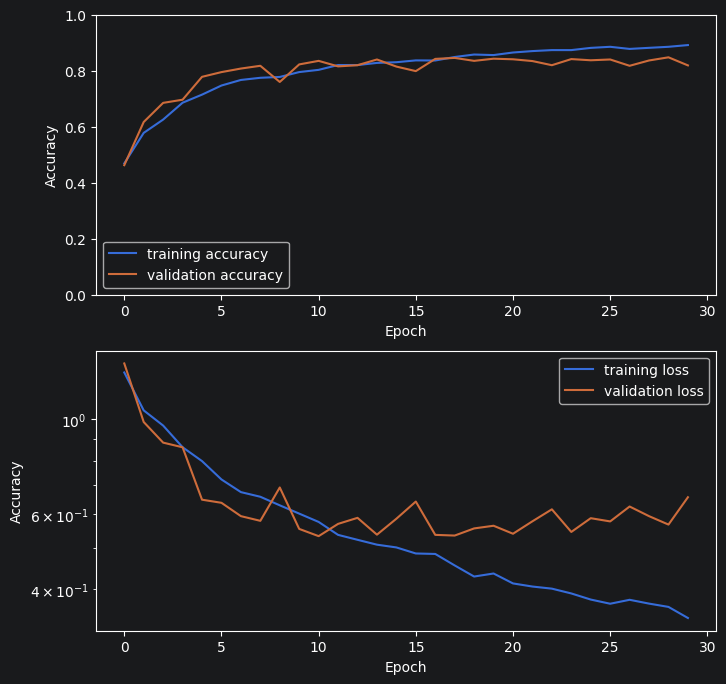

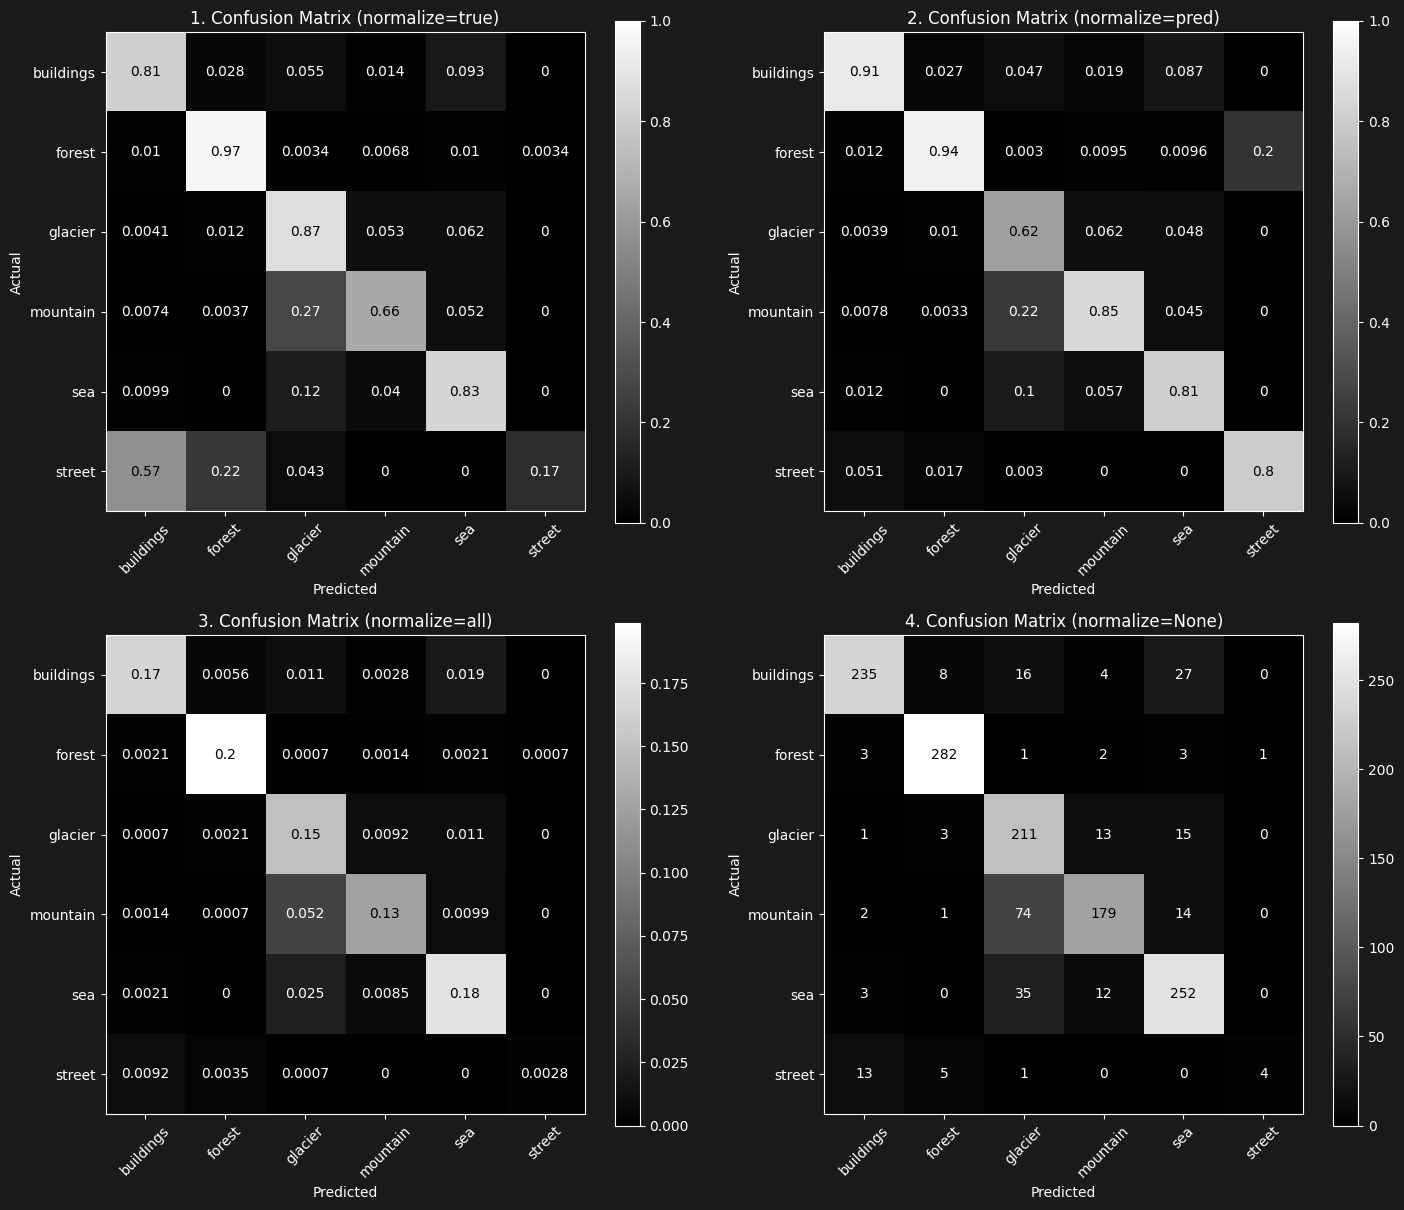

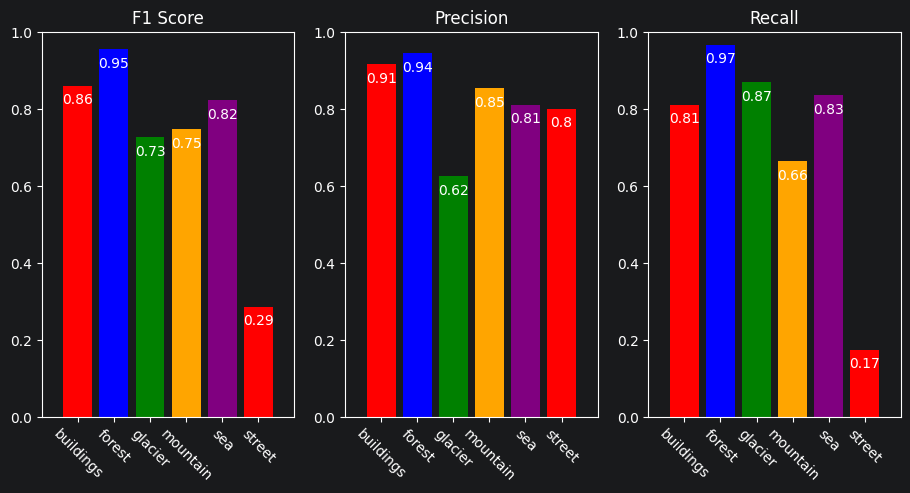

In [7]:
plot_accuracy_and_loss(history.history["accuracy"], history.history["val_accuracy"], history.history["loss"], history.history["val_loss"])

plot_confusion_matrix(true, pred, label_names)
plot_scores(true, pred, label_names)

In [8]:
cv_results = execute_cv(create_model, dataset=train_images.concatenate(validation_images), folds=5, epochs=30)

Fold 1 / 5
Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4613 - loss: 1.3594 - val_accuracy: 0.5813 - val_loss: 1.1309
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5861 - loss: 1.0646 - val_accuracy: 0.6249 - val_loss: 0.9610
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6202 - loss: 0.9837 - val_accuracy: 0.6263 - val_loss: 0.9900
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6725 - loss: 0.8984 - val_accuracy: 0.7199 - val_loss: 0.8071
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7237 - loss: 0.8234 - val_accuracy: 0.7664 - val_loss: 0.7463
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7304 - loss: 0.7881 - val_accuracy: 0.6897 - val_loss: 0.8333
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7562 - loss: 0.7341 - val_accuracy: 0.7811 - val_loss: 0.6628
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7619 - loss: 0.7080

Mean	Std. dev.	Name
0.6343	0.0121		Train Accuracy
0.6720	0.0304		Validation Accuracy
0.9715	0.0206		Train Loss
0.9141	0.0490		Validation Loss
0.5585	0.0353		Validation F1


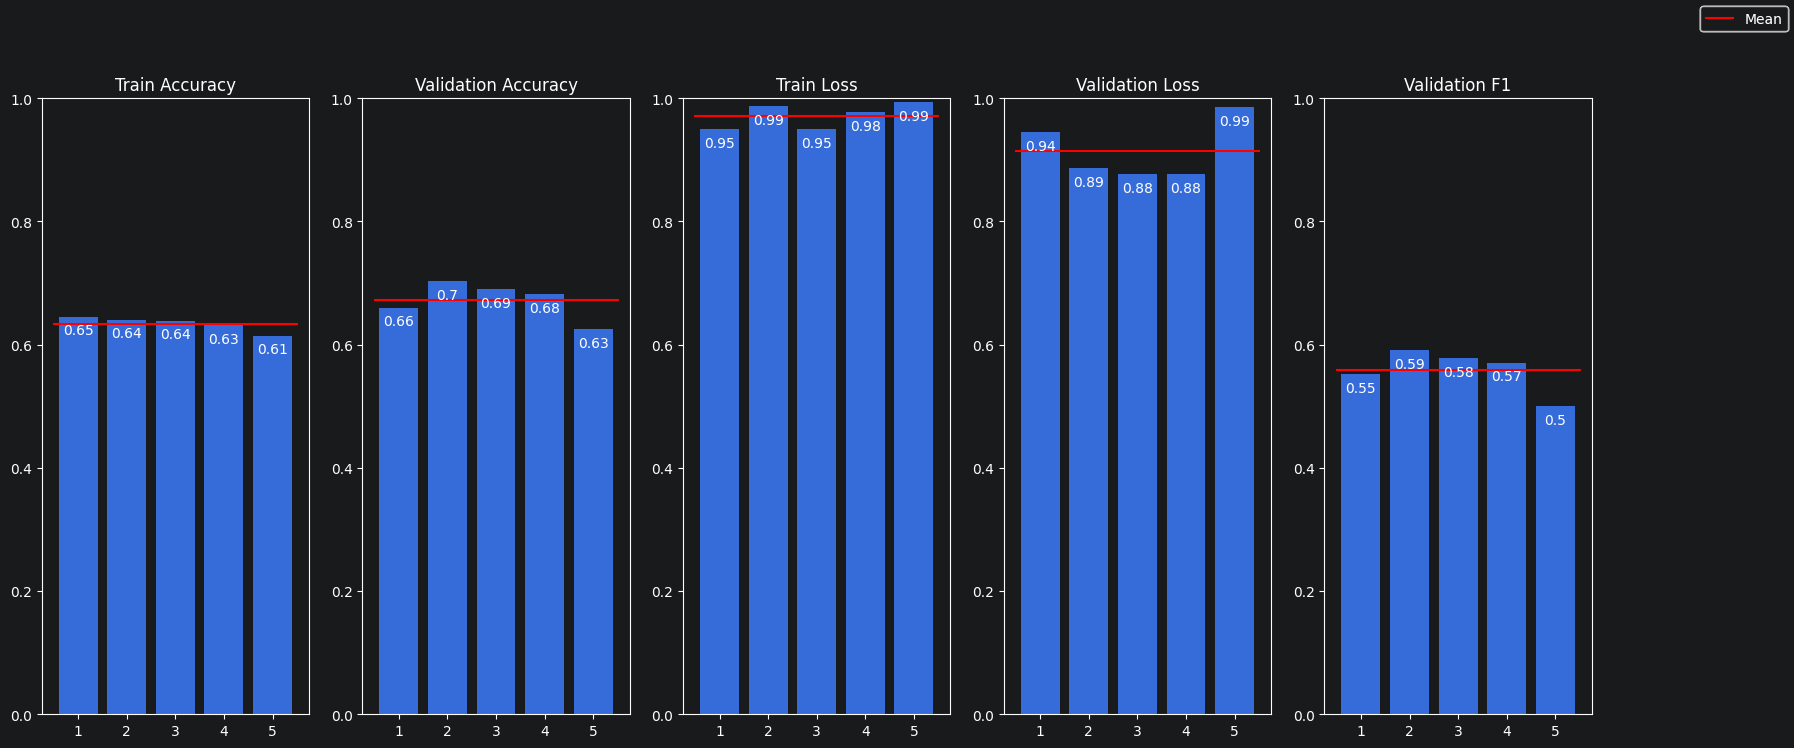

In [35]:
print("Mean\tStd. dev.\tName")
for name, values in cv_results.items():
    print(f"{mean(values):.4f}\t{stdev(values):.4f}\t\t{name}")

plot_cv_results(cv_results)